# Projeto Final do Google Data Analytics: Estudo de caso da Cyclistic

A Cyclistic é uma empresa fictícia de compartilhamento de bicicletas localizada em Chicago, que oferece opções de uso para clientes casuais e planos de assinatura para membros.

O objetivo deste projeto é entender as diferenças de uso entre os tipos de cliente e identificar oportunidades para aumentar o número de assinaturas do plano anual.

## Dados utilizados

Os dados utilizados são informações públicas disponibilizadas pela Divvy Bikes e mostram o histórico de viagens realizadas ao longo de 2025, usando dados como o tipo de cliente, os horários de início e fim das viagens, a duração e o dia da semana.

## Ferramentas

A análise foi feita no Jupyter Notebook com Python, utilizando Pandas para organizar e analisar os dados e Matplotlib para visualização.

In [1]:
import glob
import pandas as pd
import matplotlib.pyplot as plt

arquivos = sorted(glob.glob("dados/*.csv"))

df = pd.concat([pd.read_csv(arquivo) for arquivo in arquivos], ignore_index=True)

## Processamento

Os dados foram processados com a conversão das colunas de data e hora para o formato correto, o cálculo da duração das viagens e a criação de uma coluna para o dia da semana.

In [2]:
df["inicio_viagem"] = pd.to_datetime(df["started_at"])
df["fim_viagem"] = pd.to_datetime(df["ended_at"])

df["duracao_viagem"] = ((df["fim_viagem"] - df["inicio_viagem"]).dt.total_seconds() / 60)

df["dia_semana"] = df["inicio_viagem"].dt.dayofweek

## Análise

A análise compara o uso das bicicletas entre clientes casuais e membros, utilizando os dias da semana e a duração das viagens para entender as diferenças entre os tipos de cliente.

### Duração das viagens

A tabela abaixo mostra o tempo médio das viagens para cada tipo de cliente e ajuda a comparar a duração das viagens entre clientes casuais e membros.

In [3]:
df.groupby("member_casual")["duracao_viagem"].mean().round(1).reset_index()

,member_casual,duracao_viagem
0,casual,22.6
1,member,12.3


### Viagens por dia da semana

O gráfico abaixo mostra o número de viagens em cada dia da semana e compara os padrões de uso entre clientes casuais e membros ao longo da semana.

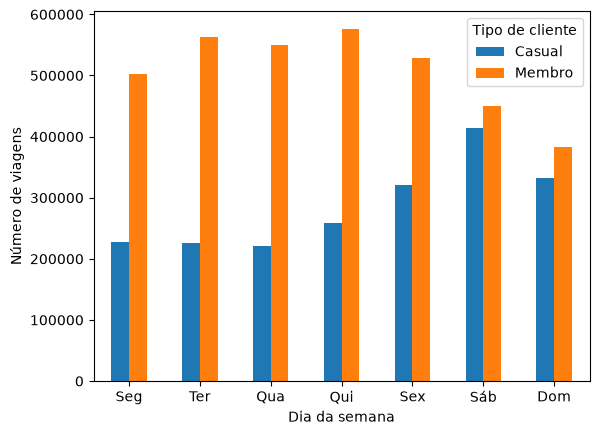

In [4]:
df.groupby(["dia_semana", "member_casual"]).size().unstack().plot(kind="bar")

plt.xlabel("Dia da semana")
plt.ylabel("Número de viagens")
plt.legend(["Casual", "Membro"], title="Tipo de cliente")
plt.xticks(range(7), ["Seg", "Ter", "Qua", "Qui", "Sex", "Sáb", "Dom"], rotation=0)

plt.savefig("grafico-uso-semanal-cyclistic.png", dpi=300, bbox_inches="tight")

plt.show()

## Conclusão

A análise mostrou que clientes casuais fazem viagens mais longas e utilizam o serviço com mais frequência aos finais de semana, enquanto membros fazem viagens mais curtas e utilizam o serviço com maior frequência durante a semana.

## Recomendações

A empresa pode mostrar no aplicativo a diferença de preço entre viagens avulsas e o plano anual, apresentar o plano em alguns momentos após o fim da viagem e oferecer um período de teste gratuito.